# Unsupervised Learning — From Basics to Advanced

No labels this time — just $\{x^{(i)}\}_{i=1}^n$. The goal is to discover **structure**: groups, lower-dimensional representations, densities, or anomalies.

---

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.frameon": False,
})
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#be185d"]
print("Environment ready.")

Environment ready.


## 1. What Is Unsupervised Learning?

Three big families:

1. **Clustering** — group similar points together (K-Means, Hierarchical, DBSCAN, GMM).
2. **Dimensionality reduction** — compress features while keeping structure (PCA, t-SNE, Autoencoders).
3. **Density estimation / anomaly detection** — model "normal" data to flag outliers (Isolation Forest, GMM).

There's no ground truth to check against, so evaluation relies on **internal metrics** (e.g. silhouette score) or **downstream usefulness**.

## 2. K-Means Clustering

### 2.1 Objective
Partition $n$ points into $K$ clusters to minimize **within-cluster sum of squares (inertia)**:
$$J = \sum_{k=1}^K \sum_{x^{(i)} \in C_k} \|x^{(i)} - \mu_k\|^2$$
where $\mu_k$ is the centroid of cluster $k$. This is NP-hard in general, so K-Means uses an iterative heuristic (**Lloyd's algorithm**):

1. Initialize $K$ centroids (e.g. K-Means++).
2. **Assign** each point to its nearest centroid.
3. **Update** each centroid to the mean of its assigned points.
4. Repeat 2–3 until assignments stop changing.

Guaranteed to converge (inertia decreases every step) but only to a **local** optimum — hence multiple random restarts (`n_init`).

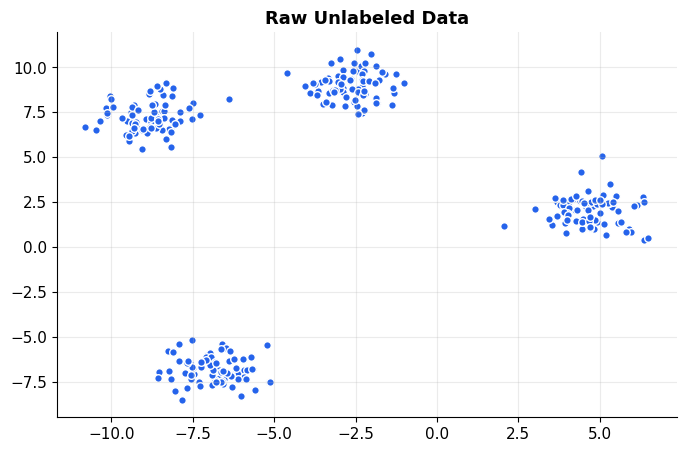

In [2]:
X_blob, y_blob_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.scatter(X_blob[:,0], X_blob[:,1], s=30, color=COLORS[0], edgecolor='white')
plt.title("Raw Unlabeled Data")
plt.show()

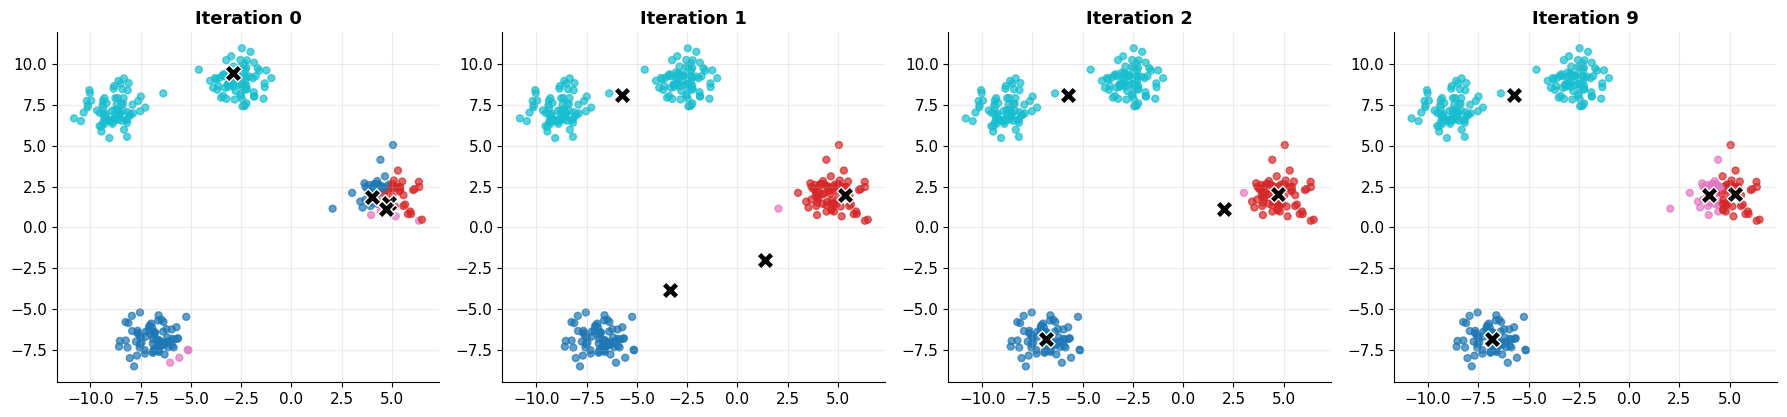

In [3]:
# --- K-Means from scratch (Lloyd's algorithm), animated via snapshots ---
def kmeans_scratch(X, k, n_iter=10, seed=0):
    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]
    snapshots = []
    for _ in range(n_iter):
        dists = np.linalg.norm(X[:,None,:] - centroids[None,:,:], axis=2)
        labels = dists.argmin(axis=1)
        snapshots.append((centroids.copy(), labels.copy()))
        new_centroids = np.array([X[labels==j].mean(axis=0) if np.any(labels==j) else centroids[j] for j in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels, snapshots

centroids, labels, snapshots = kmeans_scratch(X_blob, k=4, seed=1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
steps_to_show = [0, 1, 2, len(snapshots)-1]
for ax, step in zip(axes, steps_to_show):
    c, l = snapshots[step]
    ax.scatter(X_blob[:,0], X_blob[:,1], c=l, cmap='tab10', s=25, alpha=0.7)
    ax.scatter(c[:,0], c[:,1], c='black', marker='X', s=150, edgecolor='white')
    ax.set_title(f"Iteration {step}")
plt.tight_layout(); plt.show()

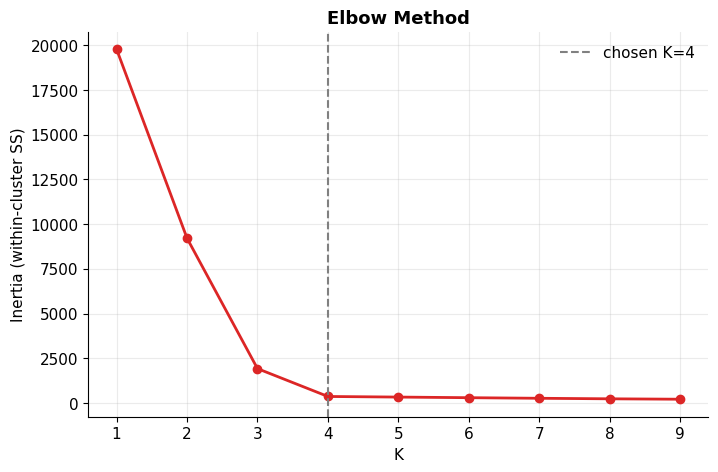

In [4]:
from sklearn.cluster import KMeans

# --- Elbow method: choosing K ---
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blob)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'o-', color=COLORS[1], lw=2)
plt.title("Elbow Method"); plt.xlabel("K"); plt.ylabel("Inertia (within-cluster SS)")
plt.axvline(4, color='gray', ls='--', label='chosen K=4')
plt.legend(); plt.show()

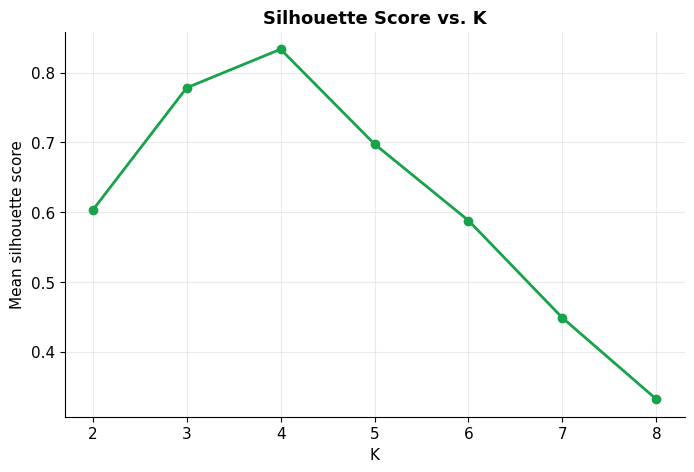

Best K by silhouette: 4


In [5]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil_scores = [silhouette_score(X_blob, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_blob))
              for k in range(2, 9)]
plt.plot(range(2,9), sil_scores, 'o-', color=COLORS[2], lw=2)
plt.title("Silhouette Score vs. K"); plt.xlabel("K"); plt.ylabel("Mean silhouette score")
plt.show()
print(f"Best K by silhouette: {list(range(2,9))[np.argmax(sil_scores)]}")

**Silhouette score** for point $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
$a(i)$ = mean distance to points in its own cluster; $b(i)$ = mean distance to points in the nearest *other* cluster. Ranges $[-1, 1]$; higher is better-separated.

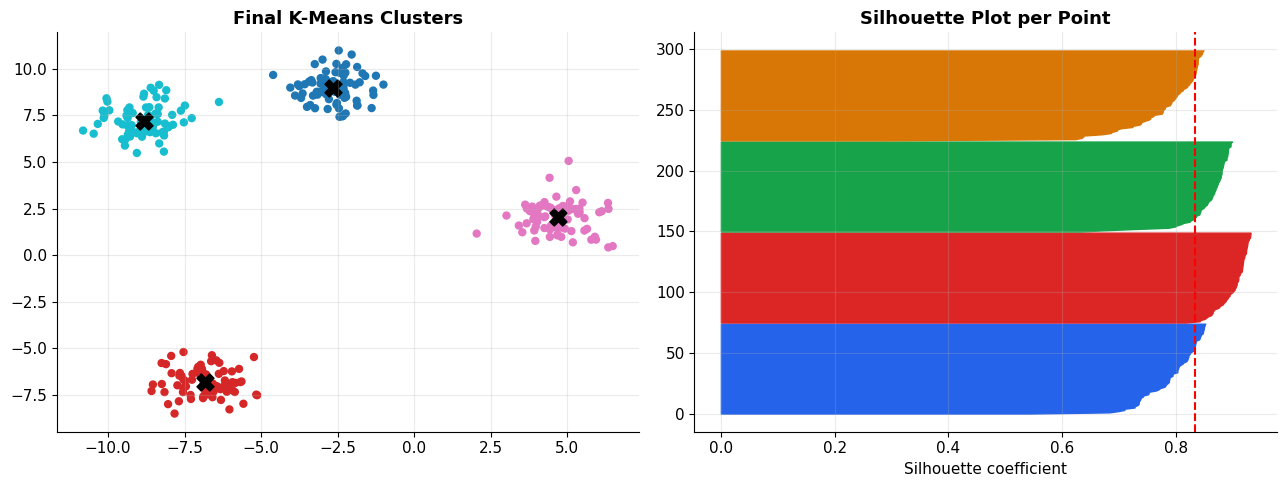

In [6]:
km_final = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_blob)
sample_sil = silhouette_samples(X_blob, km_final.labels_)

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].scatter(X_blob[:,0], X_blob[:,1], c=km_final.labels_, cmap='tab10', s=25)
axes[0].scatter(km_final.cluster_centers_[:,0], km_final.cluster_centers_[:,1], c='black', marker='X', s=150)
axes[0].set_title("Final K-Means Clusters")

y_lower = 0
for k in range(4):
    vals = np.sort(sample_sil[km_final.labels_==k])
    axes[1].fill_betweenx(np.arange(y_lower, y_lower+len(vals)), 0, vals, color=COLORS[k])
    y_lower += len(vals)
axes[1].axvline(sample_sil.mean(), color='red', ls='--')
axes[1].set_title("Silhouette Plot per Point"); axes[1].set_xlabel("Silhouette coefficient")
plt.tight_layout(); plt.show()

### 2.2 Limitation: Non-convex clusters
K-Means assumes clusters are roughly spherical (it's really doing Voronoi partitioning). It fails on interleaved, non-convex shapes like the "moons" dataset.

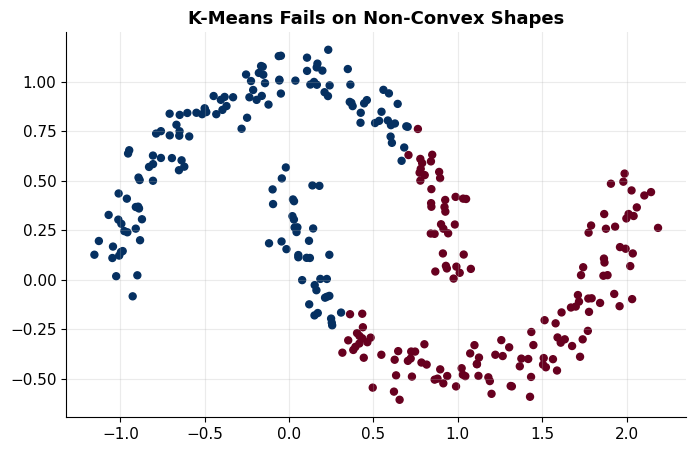

In [7]:
X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
km_moons = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moons)

plt.scatter(X_moons[:,0], X_moons[:,1], c=km_moons.labels_, cmap='RdBu_r', s=25)
plt.title("K-Means Fails on Non-Convex Shapes")
plt.show()

## 3. Hierarchical (Agglomerative) Clustering

Bottom-up: start with every point as its own cluster, repeatedly merge the two **closest** clusters, until one remains. Distance between clusters (**linkage**):

- **Single**: $\min_{a \in A, b \in B} d(a,b)$ — chains, sensitive to noise.
- **Complete**: $\max_{a \in A, b \in B} d(a,b)$ — compact clusters.
- **Average**: mean pairwise distance.
- **Ward**: merges that minimize increase in total within-cluster variance (most common default).

The full merge history is visualized as a **dendrogram**; cutting it horizontally at some height gives a clustering.

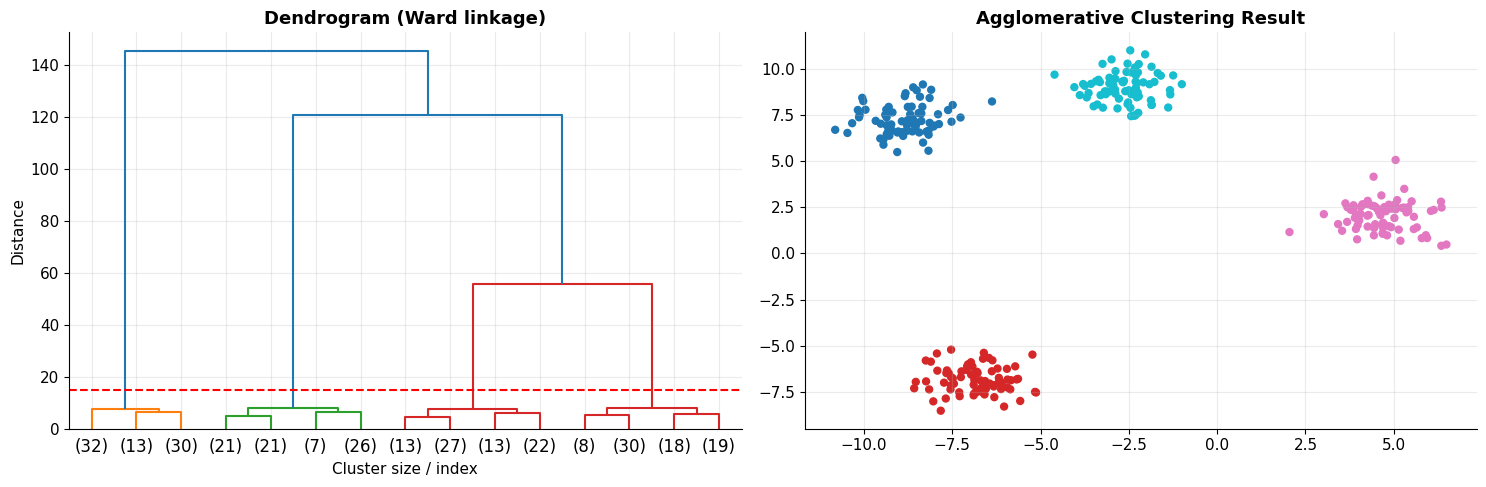

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Z = linkage(X_blob, method='ward')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=15)
axes[0].set_title("Dendrogram (Ward linkage)")
axes[0].axhline(15, color='red', ls='--')
axes[0].set_xlabel("Cluster size / index"); axes[0].set_ylabel("Distance")

agg = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X_blob)
axes[1].scatter(X_blob[:,0], X_blob[:,1], c=agg.labels_, cmap='tab10', s=25)
axes[1].set_title("Agglomerative Clustering Result")
plt.tight_layout(); plt.show()

## 4. DBSCAN (Density-Based Clustering)

Groups points that are **densely packed**, marking sparse points as noise. Two parameters:
- $\varepsilon$ — neighborhood radius.
- `min_samples` — minimum points within $\varepsilon$ to be a "core point".

A point is a **core point** if it has $\geq$ `min_samples` neighbors within $\varepsilon$. Clusters grow by chaining core points together; points reachable from a core point but not core themselves are **border points**; everything else is **noise**.

Big advantage over K-Means: finds arbitrarily-shaped clusters and **doesn't need $K$ specified**.

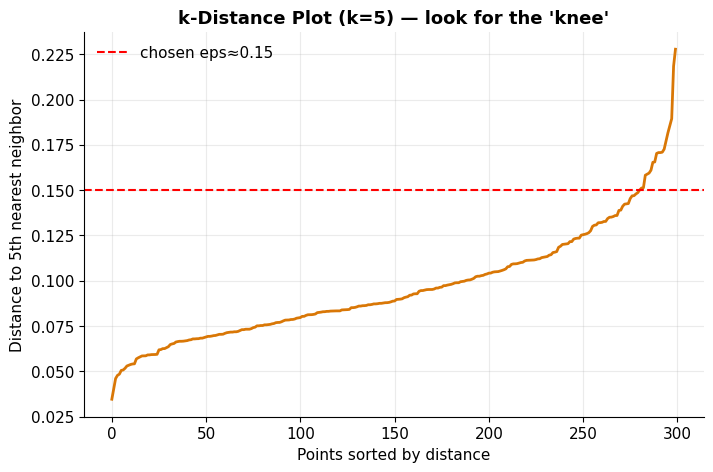

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance plot to help choose eps
neighbors = NearestNeighbors(n_neighbors=5).fit(X_moons)
distances, _ = neighbors.kneighbors(X_moons)
k_distances = np.sort(distances[:,-1])

plt.plot(k_distances, color=COLORS[3], lw=2)
plt.title("k-Distance Plot (k=5) — look for the 'knee'")
plt.xlabel("Points sorted by distance"); plt.ylabel("Distance to 5th nearest neighbor")
plt.axhline(0.15, color='red', ls='--', label='chosen eps≈0.15')
plt.legend(); plt.show()

Clusters found: 2, noise points: 2


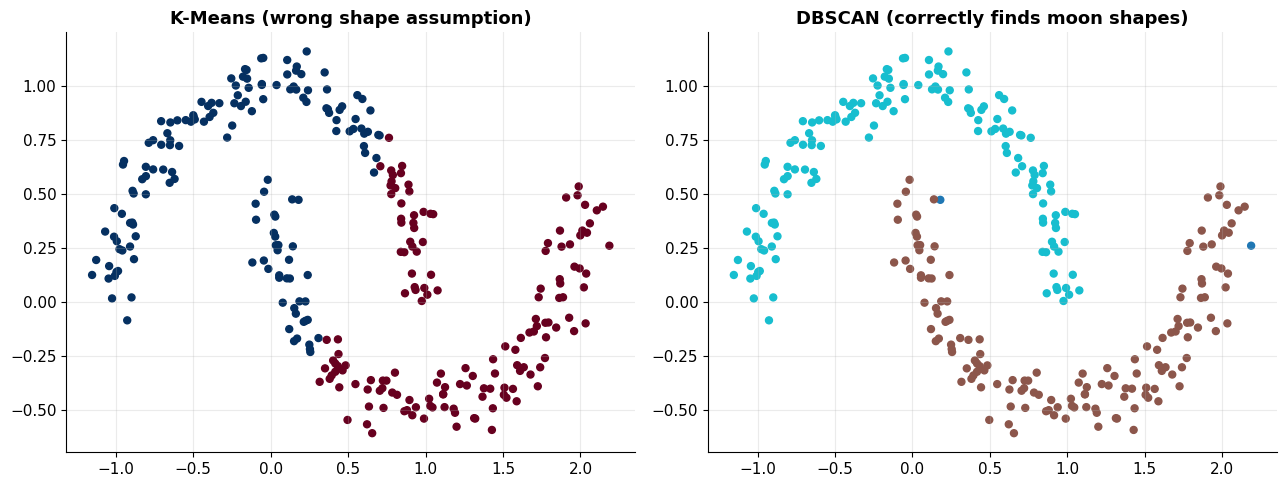

In [10]:
db = DBSCAN(eps=0.15, min_samples=5).fit(X_moons)
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = np.sum(db.labels_ == -1)
print(f"Clusters found: {n_clusters}, noise points: {n_noise}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_moons[:,0], X_moons[:,1], c=km_moons.labels_, cmap='RdBu_r', s=25)
axes[0].set_title("K-Means (wrong shape assumption)")
axes[1].scatter(X_moons[:,0], X_moons[:,1], c=db.labels_, cmap='tab10', s=25)
axes[1].set_title("DBSCAN (correctly finds moon shapes)")
plt.tight_layout(); plt.show()

## 5. Gaussian Mixture Models (GMM)

A **probabilistic** clustering model: data is assumed generated from a mixture of $K$ Gaussians.
$$p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$
Unlike K-Means (hard assignment), GMM gives **soft** cluster membership probabilities and can model elliptical (not just spherical) clusters. Fit via **Expectation-Maximization (EM)**:

- **E-step**: compute responsibility $\gamma_{ik} = P(z_i=k \mid x_i)$ given current parameters.
- **M-step**: update $\pi_k, \mu_k, \Sigma_k$ using those responsibilities as weights.
- Repeat until log-likelihood converges.

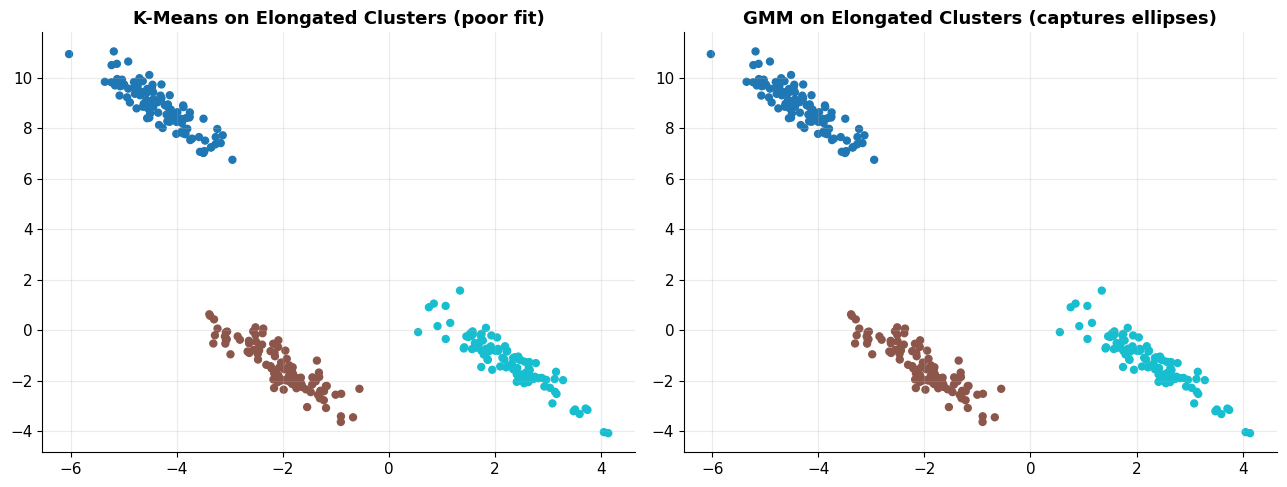

In [11]:
from sklearn.mixture import GaussianMixture

X_elong, y_elong = make_blobs(n_samples=300, centers=3, random_state=42)
transformation = [[0.6, -0.6], [-0.3, 0.8]]
X_elong = X_elong @ transformation  # stretch into ellipses

gmm = GaussianMixture(n_components=3, random_state=42).fit(X_elong)
labels_gmm = gmm.predict(X_elong)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(X_elong[:,0], X_elong[:,1], c=KMeans(3, n_init=10, random_state=42).fit_predict(X_elong), cmap='tab10', s=25)
axes[0].set_title("K-Means on Elongated Clusters (poor fit)")
axes[1].scatter(X_elong[:,0], X_elong[:,1], c=labels_gmm, cmap='tab10', s=25)
axes[1].set_title("GMM on Elongated Clusters (captures ellipses)")
plt.tight_layout(); plt.show()

## 6. Principal Component Analysis (PCA)

### 6.1 Goal
Find a lower-dimensional subspace that preserves as much **variance** as possible.

### 6.2 Math
1. Center the data: $X \leftarrow X - \bar{X}$.
2. Compute the covariance matrix: $\Sigma = \frac{1}{n} X^\top X$.
3. Find eigenvectors/eigenvalues of $\Sigma$: $\Sigma v_i = \lambda_i v_i$.
4. Sort eigenvectors by eigenvalue (descending) — these are the **principal components**; $\lambda_i$ is the variance captured along $v_i$.
5. Project: $X_{\text{reduced}} = X V_k$ where $V_k$ holds the top $k$ eigenvectors.

**Explained variance ratio**: $\lambda_i / \sum_j \lambda_j$ — how much of the total variance component $i$ accounts for.

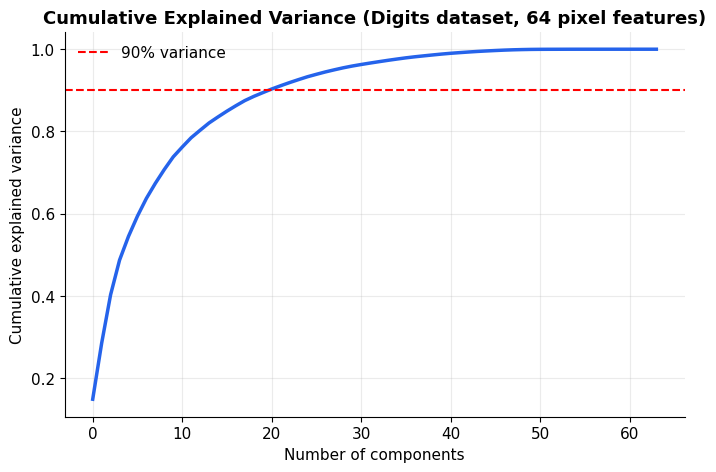

Components needed for 90% variance: 21 (down from 64)


In [12]:
from sklearn.decomposition import PCA

digits = load_digits()
X_dig, y_dig = digits.data, digits.target
X_dig_c = X_dig - X_dig.mean(axis=0)

pca_full = PCA().fit(X_dig_c)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(cum_var, color=COLORS[0], lw=2.5)
plt.axhline(0.90, color='red', ls='--', label='90% variance')
plt.title("Cumulative Explained Variance (Digits dataset, 64 pixel features)")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance"); plt.legend()
plt.show()
n90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components needed for 90% variance: {n90} (down from {X_dig.shape[1]})")

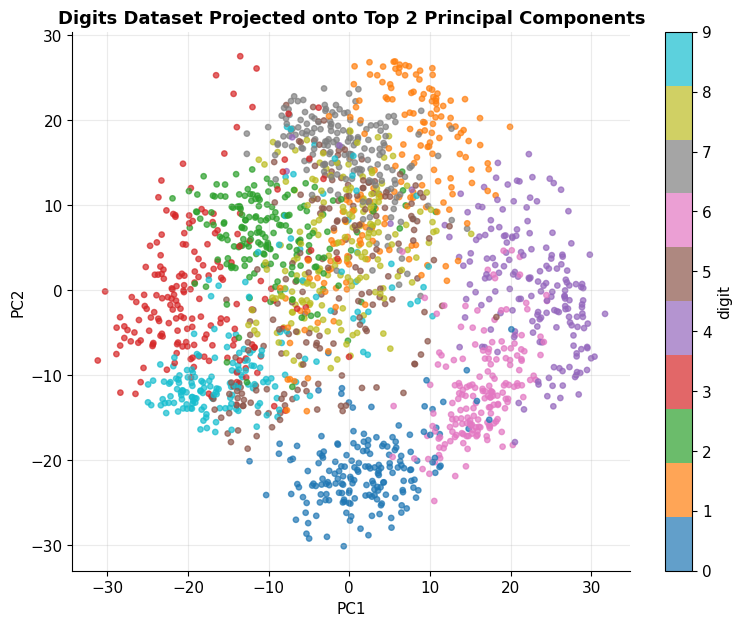

In [13]:
pca2 = PCA(n_components=2).fit_transform(X_dig_c)

plt.figure(figsize=(9,7))
scatter = plt.scatter(pca2[:,0], pca2[:,1], c=y_dig, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='digit')
plt.title("Digits Dataset Projected onto Top 2 Principal Components")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

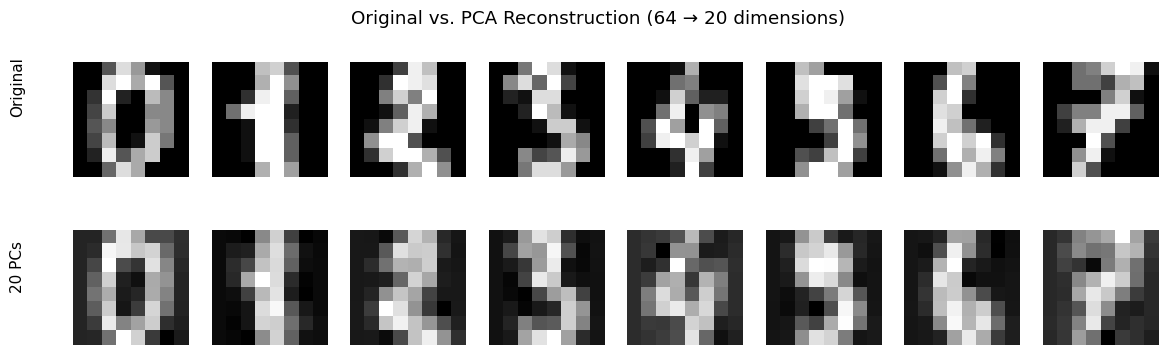

In [14]:
# Reconstruction: PCA is lossy compression
pca_recon = PCA(n_components=20).fit(X_dig_c)
X_recon = pca_recon.inverse_transform(pca_recon.transform(X_dig_c)) + X_dig.mean(axis=0)

fig, axes = plt.subplots(2, 8, figsize=(14,4))
for i in range(8):
    axes[0,i].imshow(X_dig[i].reshape(8,8), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(X_recon[i].reshape(8,8), cmap='gray'); axes[1,i].axis('off')
axes[0,0].set_ylabel("Original", fontsize=10)
fig.text(0.08, 0.72, 'Original', rotation=90, fontsize=11)
fig.text(0.08, 0.28, '20 PCs', rotation=90, fontsize=11)
plt.suptitle("Original vs. PCA Reconstruction (64 → 20 dimensions)")
plt.show()

## 7. t-SNE (t-Distributed Stochastic Neighbor Embedding)

PCA preserves **global** variance (linear); t-SNE preserves **local neighborhoods** (non-linear) — great for visualization, not for general-purpose feature reduction (no simple inverse transform, non-deterministic, distances between far-apart clusters aren't meaningful).

**Core idea**: convert pairwise distances in high-D into probabilities (points close together in original space → high probability of being neighbors) via a Gaussian; do the same in low-D via a **Student-t distribution** (heavier tails, avoids crowding); then minimize the KL-divergence between the two distributions using gradient descent.
$$p_{j|i} = \frac{\exp(-\|x_i-x_j\|^2/2\sigma_i^2)}{\sum_{k\neq i}\exp(-\|x_i-x_k\|^2/2\sigma_i^2)}, \qquad q_{j|i} = \frac{(1+\|y_i-y_j\|^2)^{-1}}{\sum_{k\neq i}(1+\|y_i-y_k\|^2)^{-1}}$$
$$\text{KL}(P\|Q) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$

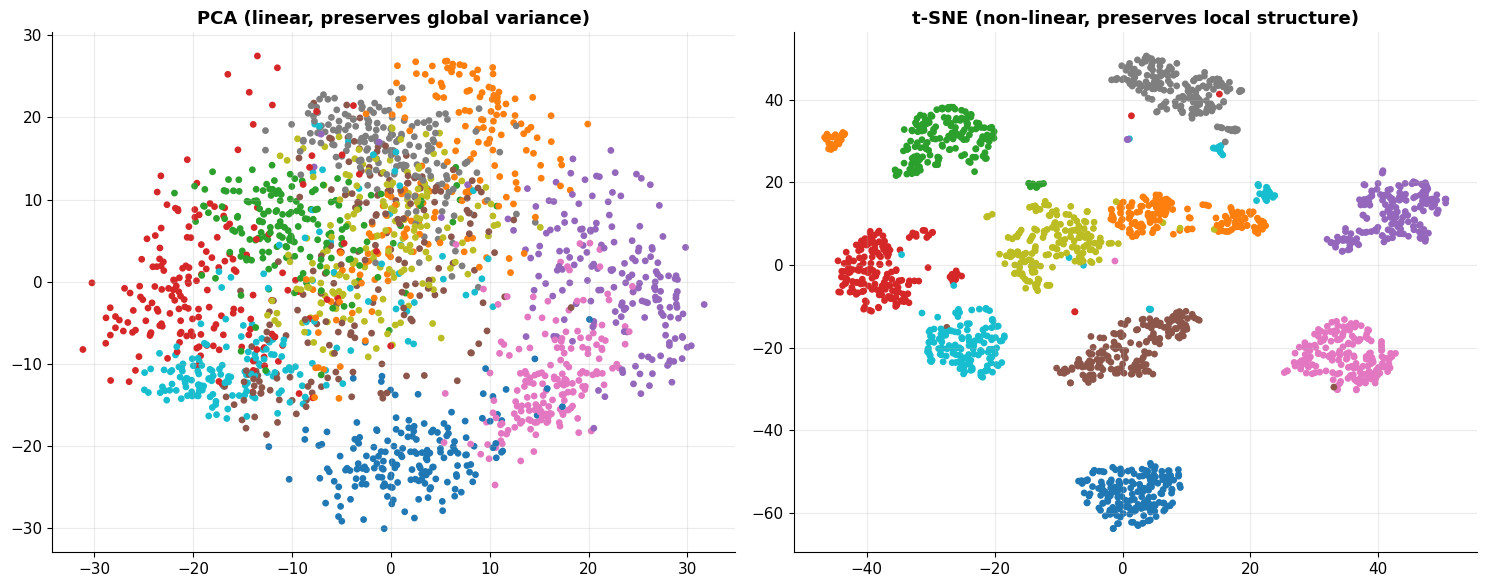

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_dig)

fig, axes = plt.subplots(1, 2, figsize=(15,6))
sc1 = axes[0].scatter(pca2[:,0], pca2[:,1], c=y_dig, cmap='tab10', s=15)
axes[0].set_title("PCA (linear, preserves global variance)")
sc2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_dig, cmap='tab10', s=15)
axes[1].set_title("t-SNE (non-linear, preserves local structure)")
plt.tight_layout(); plt.show()

## 8. Anomaly Detection — Isolation Forest

**Intuition**: anomalies are "few and different" — they're easier to *isolate* with random partitions than normal points. Build random trees that split on random features/thresholds; anomalies end up at **shallow depth** (isolated quickly), normal points at **greater depth**.

Anomaly score based on average path length $h(x)$ across trees, normalized against expected path length $c(n)$ for $n$ samples:
$$s(x, n) = 2^{-h(x)/c(n)}$$
Score close to 1 → anomaly; close to 0.5 → normal.

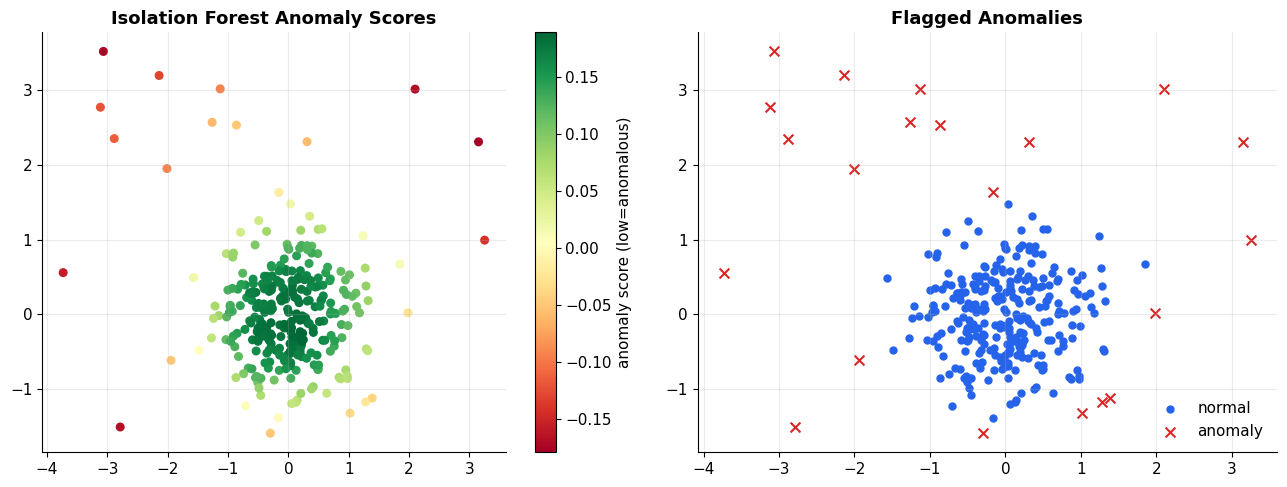

In [16]:
from sklearn.ensemble import IsolationForest

X_normal = np.random.randn(280, 2) * 0.6
X_anomaly = np.random.uniform(-4, 4, (20, 2))
X_anom_data = np.vstack([X_normal, X_anomaly])

iso = IsolationForest(contamination=0.07, random_state=42).fit(X_anom_data)
pred = iso.predict(X_anom_data)  # 1 = normal, -1 = anomaly
scores = iso.decision_function(X_anom_data)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sc = axes[0].scatter(X_anom_data[:,0], X_anom_data[:,1], c=scores, cmap='RdYlGn', s=30)
plt.colorbar(sc, ax=axes[0], label='anomaly score (low=anomalous)')
axes[0].set_title("Isolation Forest Anomaly Scores")

axes[1].scatter(X_anom_data[pred==1,0], X_anom_data[pred==1,1], color=COLORS[0], s=25, label='normal')
axes[1].scatter(X_anom_data[pred==-1,0], X_anom_data[pred==-1,1], color=COLORS[1], s=50, marker='x', label='anomaly')
axes[1].set_title("Flagged Anomalies"); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. Autoencoders — Neural Non-Linear Dimensionality Reduction

An autoencoder is a neural network trained to **reconstruct its own input**, with a narrow "bottleneck" layer in the middle forcing it to learn a compressed representation:
$$x \xrightarrow{\text{encoder } f} z \text{ (low-dim)} \xrightarrow{\text{decoder } g} \hat x, \qquad \text{minimize } \|x - \hat x\|^2$$

It's the non-linear generalization of PCA — with linear activations and MSE loss, an autoencoder's optimal solution *is* PCA. With non-linear activations it can capture curved manifolds PCA can't.

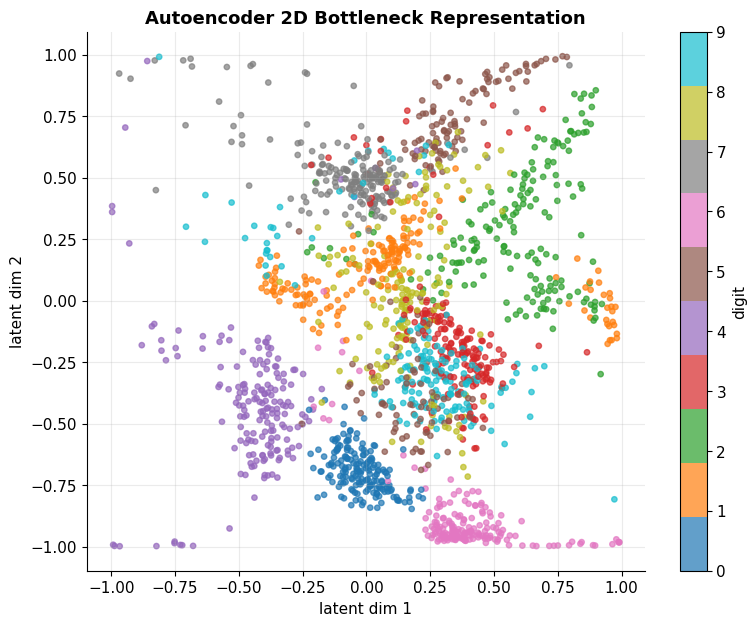

Reconstruction MSE: 0.4873


In [17]:
from sklearn.neural_network import MLPRegressor

# A single hidden-layer "autoencoder" via MLPRegressor: input=output, bottleneck=2 units
X_ae = StandardScaler().fit_transform(X_dig)
ae = MLPRegressor(hidden_layer_sizes=(32, 2, 32), activation='tanh', max_iter=1500,
                   random_state=42, alpha=1e-4).fit(X_ae, X_ae)

# grab the bottleneck (2-unit) activations by running a partial forward pass
def encode(mlp, X):
    a = X
    # first two weight matrices take us to the bottleneck layer (index 1 of hidden_layer_sizes)
    a = np.tanh(a @ mlp.coefs_[0] + mlp.intercepts_[0])
    a = np.tanh(a @ mlp.coefs_[1] + mlp.intercepts_[1])
    return a

Z = encode(ae, X_ae)
plt.figure(figsize=(9,7))
sc = plt.scatter(Z[:,0], Z[:,1], c=y_dig, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(sc, label='digit')
plt.title("Autoencoder 2D Bottleneck Representation")
plt.xlabel("latent dim 1"); plt.ylabel("latent dim 2")
plt.show()

recon = ae.predict(X_ae)
mse = np.mean((X_ae - recon)**2)
print(f"Reconstruction MSE: {mse:.4f}")

## 10. Summary Cheat-Sheet

| Algorithm | Category | Key idea | Watch out for |
|---|---|---|---|
| K-Means | Clustering | Minimize within-cluster variance, Lloyd's algorithm | Needs $K$, assumes spherical clusters |
| Hierarchical | Clustering | Bottom-up merges, dendrogram | $O(n^2)$ or worse, doesn't scale |
| DBSCAN | Clustering | Density-connected regions | Sensitive to $\varepsilon$, struggles with varying density |
| GMM | Clustering (soft) | Mixture of Gaussians, EM algorithm | Assumes Gaussian-shaped clusters |
| PCA | Dim. reduction | Project onto top variance directions (eigen-decomposition) | Linear only |
| t-SNE | Dim. reduction (viz) | Preserve local neighborhoods via KL divergence | Slow, non-deterministic, for visualization only |
| Isolation Forest | Anomaly detection | Random splits isolate outliers faster | Contamination rate must be estimated |
| Autoencoder | Dim. reduction (non-linear) | Neural bottleneck reconstruction | Needs more data/tuning than PCA |

**General workflow:** scale your features → try PCA/t-SNE just to look at the data → pick a clustering method matching your assumed cluster shape → validate with silhouette score / domain knowledge (no ground-truth labels to check against!) → for outliers, isolation forest or density-based methods.